# Python for AI — Class 15
### Pandas II: groupby, merge and new columns

Yesterday we read a table, looked at it, filtered and cleaned it.
Today we **summarise** tables, **join** two tables, and **make new columns**.

## How we will learn today

Every topic has the same 4 steps:

| Step | What happens |
|------|--------------|
| **CONCEPT** | The teacher explains the idea. Short points. |
| **EXAMPLE** | The teacher types the code. **You type it too** and run it. |
| **QUICK CHECK** | You solve a small task alone. |
| **SOLUTION** | We check the answer together. The solutions are in a separate file. |

**Tip:** Run a cell with `Shift + Enter`.

# Hour 1: groupby

## Get the data

The cell below makes two files, `students.csv` and `fees.csv`, and reads them.

In [3]:
import pandas as pd
import numpy as np

# Run this cell once. It makes two files: students.csv and fees.csv
students_text = """student_id,name,city,maths,english,science
1,Ali,Lahore,80,72,91
2,Sara,Karachi,65,88,70
3,Hassan,Lahore,95,60,84
4,Ayesha,Islamabad,72,76,78
5,Bilal,Karachi,55,64,58
6,Fatima,Lahore,88,91,95
7,Usman,Islamabad,66,58,62
8,Zainab,Karachi,92,85,89
9,Hamza,Lahore,45,50,48
10,Maryam,Islamabad,78,80,74
11,Imran,Karachi,70,68,72
12,Hira,Islamabad,85,90,88
"""
fees_text = """student_id,fee_paid,fee_amount
1,Yes,5000
2,Yes,5000
3,No,5000
5,Yes,4000
6,Yes,5000
7,No,4000
8,Yes,5000
9,No,4000
10,Yes,5000
11,Yes,4000
13,Yes,5000
"""
with open("students.csv", "w") as f:
    f.write(students_text)
with open("fees.csv", "w") as f:
    f.write(fees_text)

df = pd.read_csv("students.csv")
fees = pd.read_csv("fees.csv")

In [4]:
print(df)

    student_id    name       city  maths  english  science
0            1     Ali     Lahore     80       72       91
1            2    Sara    Karachi     65       88       70
2            3  Hassan     Lahore     95       60       84
3            4  Ayesha  Islamabad     72       76       78
4            5   Bilal    Karachi     55       64       58
5            6  Fatima     Lahore     88       91       95
6            7   Usman  Islamabad     66       58       62
7            8  Zainab    Karachi     92       85       89
8            9   Hamza     Lahore     45       50       48
9           10  Maryam  Islamabad     78       80       74
10          11   Imran    Karachi     70       68       72
11          12    Hira  Islamabad     85       90       88


In [4]:
print(fees)

    student_id fee_paid  fee_amount
0            1      Yes        5000
1            2      Yes        5000
2            3       No        5000
3            5      Yes        4000
4            6      Yes        5000
5            7       No        4000
6            8      Yes        5000
7            9       No        4000
8           10      Yes        5000
9           11      Yes        4000
10          13      Yes        5000


## CONCEPT: groupby: one answer for each group

- Sometimes we want one answer **for each group**: for each city, for each class.
- Idea: **split** the table into groups, **calculate** for each group, **combine** the answers.
- Write: `df.groupby("city")["maths"].mean()` = average Maths of each city.
- Read it left to right: group by city → take the maths column → take the mean.

### EXAMPLE: Average Maths of each city

In [5]:
print(df.groupby("city")["maths"].mean())

city
Islamabad    75.25
Karachi      70.50
Lahore       77.00
Name: maths, dtype: float64


In [11]:
print(df.groupby("city")["science"].max())     # best Science mark in each city

city
Islamabad    88
Karachi      89
Lahore       95
Name: science, dtype: int64


In [12]:
print(df.groupby("city").size())               # how many students in each city

city
Islamabad    4
Karachi      4
Lahore       4
dtype: int64


### ✏️ QUICK CHECK 1: groupby

Print the **average English mark** of each city. Then print how many students are in each city.

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: More than one answer: agg

- `.agg(["mean", "max"])` gives many answers at once.
- You can use several columns: `df.groupby("city")[["maths", "science"]].mean()`.
- `df["city"].value_counts()` is a quick way to count each value.

### EXAMPLE: Many answers at the same time

In [13]:
print(df.groupby("city")["maths"].agg(["mean", "min", "max"]))

            mean  min  max
city                      
Islamabad  75.25   66   85
Karachi    70.50   55   92
Lahore     77.00   45   95


In [15]:
print(df.groupby("city")[["maths", "english", "science"]].mean())

           maths  english  science
city                              
Islamabad  75.25    76.00    75.50
Karachi    70.50    76.25    72.25
Lahore     77.00    68.25    79.50


In [2]:
print(df["city"].value_counts())

NameError: name 'df' is not defined

### ✏️ QUICK CHECK 2: agg

Print the `min` and `max` of the `science` mark for each city.

Write your code in the cell below.

In [5]:
import matplotlib
print(matplotlib.__version__)
print(df.groupby("city")["science"].agg(["min", "max", "mean"]))

3.11.2
           min  max   mean
city                      
Islamabad   62   88  75.50
Karachi     58   89  72.25
Lahore      48   95  79.50


<function matplotlib.pyplot.show(close=None, block=None)>

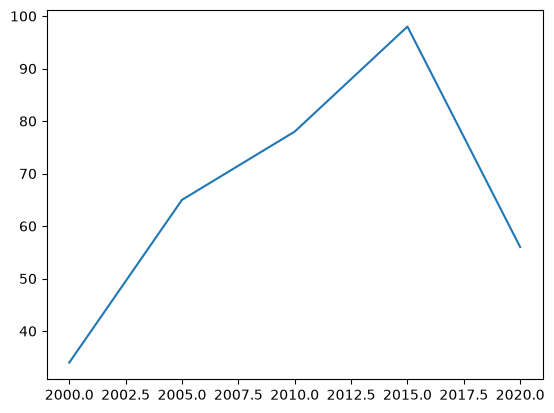

In [3]:
import matplotlib.pyplot as plt

x = [2000, 2005, 2010, 2015, 2020]
y = [34, 65, 78, 98, 56]

plt.plot(x, y)
plt.show

# Hour 2: Merging Tables

## CONCEPT: merge: join two tables

- Data is often in **different tables**. Here: marks in one table, fees in another.
- Both tables have a shared column: `student_id`. It is the **key**.
- `pd.merge(left, right, on="student_id")` puts matching rows together.
- `how="inner"` (default) keeps only the ids found in **both** tables.
- `how="left"` keeps **all** rows of the left table. If there is no match, you get `NaN`.

### EXAMPLE: Join students and fees

In [17]:
print(df.shape, fees.shape)      # 12 students, 11 fees

(12, 6) (11, 3)


In [18]:
both = pd.merge(df, fees, on="student_id")
print(both)
print(both.shape)

   student_id    name       city  maths  english  science fee_paid  fee_amount
0           1     Ali     Lahore     80       72       91      Yes        5000
1           2    Sara    Karachi     65       88       70      Yes        5000
2           3  Hassan     Lahore     95       60       84       No        5000
3           5   Bilal    Karachi     55       64       58      Yes        4000
4           6  Fatima     Lahore     88       91       95      Yes        5000
5           7   Usman  Islamabad     66       58       62       No        4000
6           8  Zainab    Karachi     92       85       89      Yes        5000
7           9   Hamza     Lahore     45       50       48       No        4000
8          10  Maryam  Islamabad     78       80       74      Yes        5000
9          11   Imran    Karachi     70       68       72      Yes        4000
(10, 8)


We have 10 rows, not 12. Students 4 and 12 have no fee row. Fee row 13 has no student. `inner` threw them all away.

Now `how="left"` (keep all students):

In [19]:
left = pd.merge(df, fees, on="student_id", how="left")
print(left)

    student_id    name       city  maths  english  science fee_paid  \
0            1     Ali     Lahore     80       72       91      Yes   
1            2    Sara    Karachi     65       88       70      Yes   
2            3  Hassan     Lahore     95       60       84       No   
3            4  Ayesha  Islamabad     72       76       78      NaN   
4            5   Bilal    Karachi     55       64       58      Yes   
5            6  Fatima     Lahore     88       91       95      Yes   
6            7   Usman  Islamabad     66       58       62       No   
7            8  Zainab    Karachi     92       85       89      Yes   
8            9   Hamza     Lahore     45       50       48       No   
9           10  Maryam  Islamabad     78       80       74      Yes   
10          11   Imran    Karachi     70       68       72      Yes   
11          12    Hira  Islamabad     85       90       88      NaN   

    fee_amount  
0       5000.0  
1       5000.0  
2       5000.0  
3       

Students 4 and 12 are still there, with `NaN` in the fee columns. Their fees are unknown.

### ✏️ QUICK CHECK 3: merge

Merge `df` and `fees` on `student_id` with `how="left"`. Save it as `report`. Print `report.shape` and the rows where `fee_paid` is missing.

Write your code in the cell below.

In [ ]:
# Write your code here

# Hour 3: New Columns, Export and Practice

## CONCEPT: Make new columns (feature creation)

- A new column is made like a dictionary: `df["new"] = ...`.
- You can use maths on other columns: `df["total"] = df["maths"] + df["english"]`.
- The maths runs on every row at once. No loop.
- A new useful column is called a **feature**. AI models learn from features.

### EXAMPLE: Total and average

In [ ]:
df["total"] = df["maths"] + df["english"] + df["science"]
print(df[["name", "total"]])

In [ ]:
df["average"] = (df["total"] / 3).round(1)
print(df[["name", "total", "average"]])

### ✏️ QUICK CHECK 4: New column

Add a column `best` to `df`. It should hold the highest of the three marks for each student. (Hint: `df[["maths", "english", "science"]].max(axis=1)`.) Print `name` and `best`.

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: A column from a condition: np.where

- `np.where(condition, a, b)` gives `a` where the condition is True, and `b` where it is False.
- Great for labels like Pass / Fail.

### EXAMPLE: Pass or Fail

In [ ]:
df["result"] = np.where(df["average"] >= 60, "Pass", "Fail")
print(df[["name", "average", "result"]])

In [ ]:
print(df["result"].value_counts())

### ✏️ QUICK CHECK 5: np.where

Add a column `level`. It is `"High"` if `maths` is 80 or more, and `"Normal"` if not. Print `name`, `maths` and `level`.

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Export: save a table

- `df.to_csv("file.csv", index=False)` saves a CSV. `index=False` = do not save the 0, 1, 2 numbers.
- `df.to_excel("file.xlsx", index=False)` saves an Excel file. It needs the `openpyxl` library. Colab has it. On your own machine: `pip install openpyxl`.
- To check the file, read it back with `pd.read_csv`.

### EXAMPLE: Save the report

In [ ]:
df.to_csv("report.csv", index=False)
print(pd.read_csv("report.csv").head(3))

In [ ]:
df.to_excel("report.xlsx", index=False)
print("Excel file saved")

### ✏️ QUICK CHECK 6: Export

Save only the columns `name`, `total` and `result` to a file called `result.csv`. Read it back and print it.

Write your code in the cell below.

In [ ]:
# Write your code here

# Practice

### ✏️ QUICK CHECK 7: Practice

Which city has the **highest average total mark**? Use `groupby` on `city` with the `total` column. Print the averages, sorted from high to low.

Write your code in the cell below.

In [ ]:
# Write your code here

### ✏️ QUICK CHECK 8: Practice (Harder)

1) Merge `df` and `fees` with `how="inner"` into `report`.
2) Find the average `total` of students who paid the fee, and of students who did not pay. (Hint: `groupby("fee_paid")`.)
3) Save `report` to `final_report.csv`.

Write your code in the cell below.

In [ ]:
# Write your code here

# Home Practice: Interview-Style Questions

1. Explain `groupby` in your own words. Use an example.
2. What is the difference between `how="inner"` and `how="left"` in a merge?
3. What is a key column in a merge?
4. How do you add a new column to a DataFrame? Give an example.
5. What does `np.where` do?
6. Why do we write `index=False` in `to_csv`?

**Extra:** Using `students.csv`, find the student with the highest total in each city. (Hint: sort by `total`, then `groupby("city").head(1)`.)

# Key Takeaways

- `groupby("col")["other"].mean()` = one answer for each group. Use `agg` for many answers.
- `pd.merge(a, b, on="key")` joins two tables. `inner` = both. `left` = all of the left table.
- A new column: `df["new"] = ...`. The maths runs on every row.
- `np.where(condition, a, b)` makes a column from a condition.
- `to_csv(..., index=False)` and `to_excel(..., index=False)` save your table.

**Next class:** Matplotlib and Seaborn: draw charts of this data.